# STRATA — ¿qué aporta la supervisión estadística? (informe de decisión, AutoML)

**Cuaderno EXPLORATORIO (no canónico).** Rama `feat/quant-validation-panel`.

Este informe se lee como una **due-diligence de un quant a un comité de inversión**: ¿merece la pena la capa
de supervisión STRATA sobre un agente LLM de trading? Lo demostramos en cuatro pasos:

1. **Caso de estudio SPY** — qué aporta STRATA en el activo central (rescate del agente y de B&H; razones).
2. **Efecto de STRATA en el panel (15 activos)** — ablación (¿cuánto añaden las features STRATA?) + SHAP
   (¿en qué se apoya el modelo? — hipótesis de universalidad §2.3).
3. **Rendimiento** — accuracy (medida central), Sharpe y max drawdown; la ventaja en **riesgo** contrastada
   con **bootstrap pareado**.
4. **Clustering por naturaleza** — según el tipo de activo, qué estrategia/modelo funciona mejor.

**Reglas de honestidad (las lleva el informe, no las esconde):**
- En accuracy, batir al naïve **ZeroR** (apostar la clase mayoritaria) es **nominal, no significativo**: con
  n≈250 no hay potencia (→ línea futura). No se afirma "batir a ZeroR" de forma significativa.
- El **valor robusto y contrastable** está en el **riesgo** (Sharpe/maxDD): ahí sí se reporta significancia
  por bootstrap. El "rescate de B&H" es **condicional al activo** (real donde el activo cae; en mercados
  alcistas B&H es difícil de batir) — y eso enlaza con el clustering.

Estrategias: **M5** agente LLM · **M8** STRATA (regla) · **M10** meta-learner XGBoost (canónico) · **AutoML**
(búsqueda H2O) · **ZeroR** clase mayoritaria · **B&H** comprar-y-mantener.

In [1]:
# --- Bootstrap raíz + carga de JSON auditados ---
import os, sys, json, glob, warnings
from pathlib import Path
_ROOT = Path.cwd()
while not (_ROOT / "config.py").exists() and _ROOT != _ROOT.parent:
    _ROOT = _ROOT.parent
os.chdir(_ROOT); sys.path.insert(0, str(_ROOT)); warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

DP = json.load(open("outputs/experiments/decision_automl_prep.json"))
PAN = json.load(open("outputs/experiments/automl_runs/"
                     "panel_mm25_inclGBM-XGB-SE_AUC_emb1_N0-150_step21_kfold_seed42.json"))["por_activo"]
IMP = json.load(open("outputs/experiments/automl_importance.json"))["por_activo"]
CLU = json.load(open("outputs/experiments/strategy_clustering15.json"))

DPA = DP["por_activo"]
ASSETS = [a for a in DP["meta"]["panel"] if a in DPA and "error" not in DPA[a]]
COL = {"M5": "#9e9e9e", "M8": "#f0a830", "M10": "#2c7fb8", "AutoML": "#27ae60",
       "ZeroR": "#7d3c98", "B&H": "#c0392b"}
REGCOL = {0: "#2e9e4f", 1: "#e8a33d", 2: "#c0392b"}  # Calma/Estrés/Crisis
# claves: panel usa m10_xgb; prep usa m10. Mapa estrategia→(panel, prep)
PKEY = {"M5": "m5", "M8": "m8", "M10": "m10_xgb", "AutoML": "automl", "ZeroR": "zeror", "B&H": "bh"}
DKEY = {"M5": "m5", "M8": "m8", "M10": "m10", "ZeroR": "zeror", "B&H": "bh"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
print("activos:", len(ASSETS), "·", ", ".join(ASSETS))
print("ventana:", DP["meta"]["ventana"])
print("M10:", DP["meta"]["m10"])

activos: 15 · SPY, QQQ, DIA, IWM, XLE, XLF, XLK, NVDA, BAC, TSLA, MSTR, SMCI, ROKU, MARA, UNG
ventana: walk-forward M10 (~250 d tras burn-in 150)
M10: canónico: ensemble 10 XGBoost, embargo=1, N0=150, ALL22 (quant_validation_panel.wf_p1)


## §1. Caso de estudio: SPY

SPY (S&P 500) es el caso central: es donde el **leverage effect** (Black 1976) es fuerte —la alta volatilidad
coincide con caídas—, así que el régimen del HMM funciona como **proxy direccional** y la supervisión tiene
de dónde agarrarse. Empezamos aquí porque es el escaparate del mecanismo.

In [2]:
# Tabla SPY: las 6 estrategias (del panel mm25 auditado)
tab = PAN["SPY"]["table"]
def fmt_row(s):
    t = tab[PKEY[s]]
    return {"acc": t["accuracy"], "AUC": t.get("auc"), "Sharpe": t["sharpe"],
            "maxDD": t["max_dd"], "Calmar": t["calmar"], "equity": t["equity_final"]}
spy = pd.DataFrame({s: fmt_row(s) for s in COL}).T
print("=== SPY · ventana desplegable (n =", PAN['SPY']['config']['n_test'], ") ===")
with pd.option_context("display.float_format", lambda v: f"{v:.4f}"):
    print(spy)
zr = tab["zeror"]["accuracy"]
gan = max(COL, key=lambda s: tab[PKEY[s]]["accuracy"])
print(f"\nGanador en accuracy (nominal): {gan} = {tab[PKEY[gan]]['accuracy']:.4f}  (ZeroR = {zr:.4f})")
print("AutoML vs ZeroR McNemar p =", PAN['SPY']['tests']['automl_vs_zeror']['p'],
      "→ NOMINAL, no significativo (ventana corta).")

=== SPY · ventana desplegable (n = 251 ) ===
          acc    AUC  Sharpe   maxDD  Calmar  equity
M5     0.3665    NaN -3.0700 -0.3025 -0.9990  0.6990
M8     0.4422    NaN -0.4640 -0.1520 -0.3900  0.9410
M10    0.4940 0.5309 -0.6040 -0.1609 -0.4980  0.9202
AutoML 0.5737 0.5521  2.6810 -0.0551  6.9290  1.3798
ZeroR  0.5657    NaN  2.2060 -0.0982  3.1020  1.3032
B&H    0.5657    NaN  2.2060 -0.0982  3.1020  1.3032

Ganador en accuracy (nominal): AutoML = 0.5737  (ZeroR = 0.5657)
AutoML vs ZeroR McNemar p = 0.902 → NOMINAL, no significativo (ventana corta).


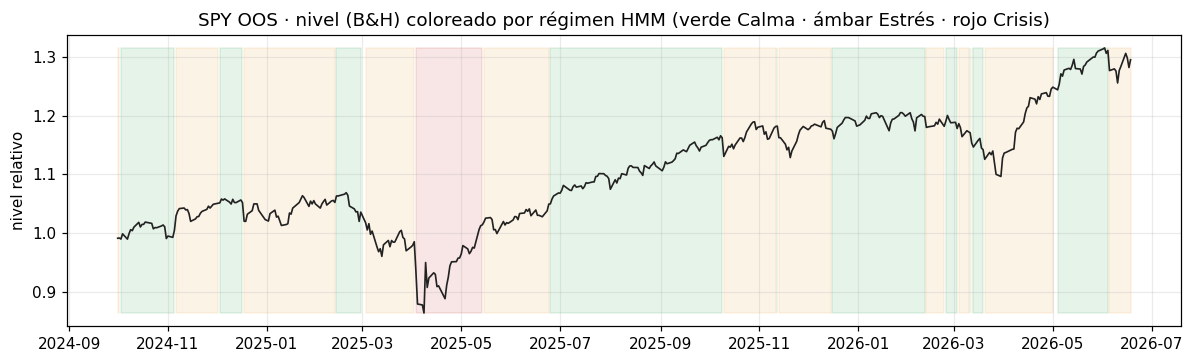

retorno medio en Crisis (signo): 1.0 → negativo = leverage effect (régimen ↔ dirección).


In [3]:
# Régimen HMM en SPY: el estado Crisis coincide con caídas (leverage effect) → régimen es direccional
from experiments.quant_validation_panel import build_states
gamma, sigma, oos_ret = build_states("SPY")
g = gamma.reindex(oos_ret.index).dropna()
dom = g.values.argmax(1)
px = (1 + oos_ret.reindex(g.index)).cumprod()
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(px.index, px.values, color="#222", lw=1.1)
for st in (0, 1, 2):
    ax.fill_between(px.index, px.min(), px.max(), where=(dom == st), color=REGCOL[st], alpha=0.12, step="mid")
ax.set_title("SPY OOS · nivel (B&H) coloreado por régimen HMM (verde Calma · ámbar Estrés · rojo Crisis)")
ax.set_ylabel("nivel relativo"); plt.tight_layout(); plt.show()
import numpy as np
cm = float(np.sign(oos_ret.reindex(g.index)[dom == 2].mean())) if (dom == 2).any() else 0.0
print("retorno medio en Crisis (signo):", cm, "→ negativo = leverage effect (régimen ↔ dirección).")

### Rescate del agente y de B&H — y por qué

El agente LLM (M5) en SPY apuesta mal direccionalmente (acc 0,37) y se arruina (Sharpe muy negativo). STRATA
**rescata**: corrige sizing y dirección con el régimen, y **de-riskea en Crisis** (recorta drawdown). Abajo,
las curvas de equity y los **Δ de riesgo con IC95 bootstrap**.

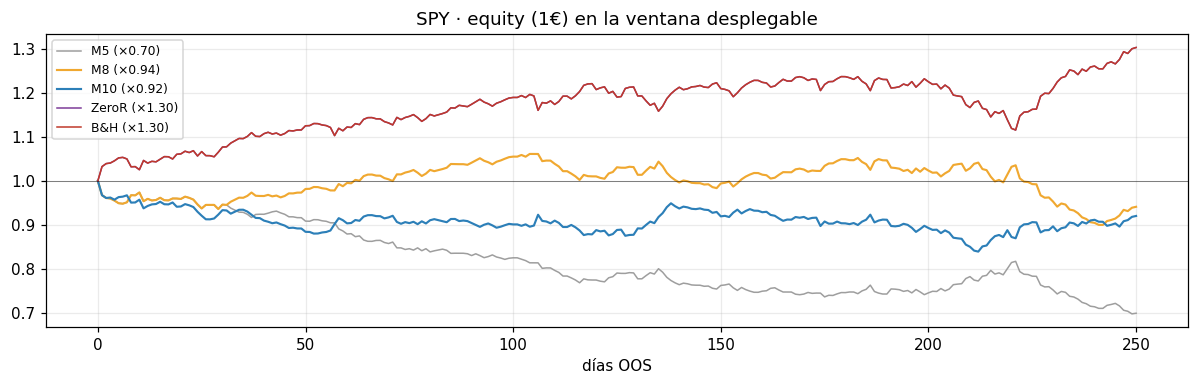

In [4]:
# Equity curves SPY (estrategias deterministas; AutoML va por su métrica de tabla)
nr = DPA["SPY"]["net_returns"]
fig, ax = plt.subplots(figsize=(11, 3.6))
for s in ("M5", "M8", "M10", "ZeroR", "B&H"):
    eq = np.cumprod(1 + np.array(nr[DKEY[s]]))
    ax.plot(eq, color=COL[s], lw=1.4 if s in ("M8", "M10") else 1.0, label=f"{s} (×{eq[-1]:.2f})")
ax.axhline(1, color="k", lw=0.6, alpha=0.5)
ax.set_title("SPY · equity (1€) en la ventana desplegable"); ax.set_xlabel("días OOS"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [5]:
# Rescate del AGENTE (M5) y de B&H: ΔSharpe y ΔmaxDD con IC95 bootstrap (M8 y M10)
boot = DPA["SPY"]["boot"]
def show_boot(metric):
    print(f"--- SPY Δ{metric} (IC95 bootstrap; sig = IC excluye 0) ---")
    for s in ("m8", "m10"):
        for b in ("m5", "bh", "zeror"):
            v = boot[f"{s}_vs_{b}"][metric]
            star = "SIG" if v["sig"] else "—"
            print(f"  {s.upper():4} vs {b.upper():5}: punto={v['point']:+.3f} IC{v['ci95']}  {star}")
show_boot("dSharpe"); print(); show_boot("dMaxDD")
print("\nLectura: vs M5 (agente) el rescate es claro; vs B&H DEPENDE del activo (en SPY, alcista, B&H es "
      "duro de batir en riesgo). El signo del 'punto' indica quién gana; 'SIG' solo dice que difieren.")

--- SPY ΔdSharpe (IC95 bootstrap; sig = IC excluye 0) ---
  M8   vs M5   : punto=+2.606 IC[-0.242, 5.9353]  —
  M8   vs BH   : punto=-2.670 IC[-5.6822, 0.4859]  —
  M8   vs ZEROR: punto=-2.670 IC[-5.6822, 0.4859]  —
  M10  vs M5   : punto=+2.466 IC[-0.5479, 5.3382]  —
  M10  vs BH   : punto=-2.810 IC[-5.6, -0.2652]  SIG
  M10  vs ZEROR: punto=-2.810 IC[-5.6, -0.2652]  SIG

--- SPY ΔdMaxDD (IC95 bootstrap; sig = IC excluye 0) ---
  M8   vs M5   : punto=+0.150 IC[-0.0174, 0.3051]  —
  M8   vs BH   : punto=-0.054 IC[-0.2298, 0.0351]  —
  M8   vs ZEROR: punto=-0.054 IC[-0.2298, 0.0351]  —
  M10  vs M5   : punto=+0.142 IC[-0.0458, 0.3427]  —
  M10  vs BH   : punto=-0.063 IC[-0.2056, 0.023]  —
  M10  vs ZEROR: punto=-0.063 IC[-0.2056, 0.023]  —

Lectura: vs M5 (agente) el rescate es claro; vs B&H DEPENDE del activo (en SPY, alcista, B&H es duro de batir en riesgo). El signo del 'punto' indica quién gana; 'SIG' solo dice que difieren.


Leader AutoML en SPY: GBM


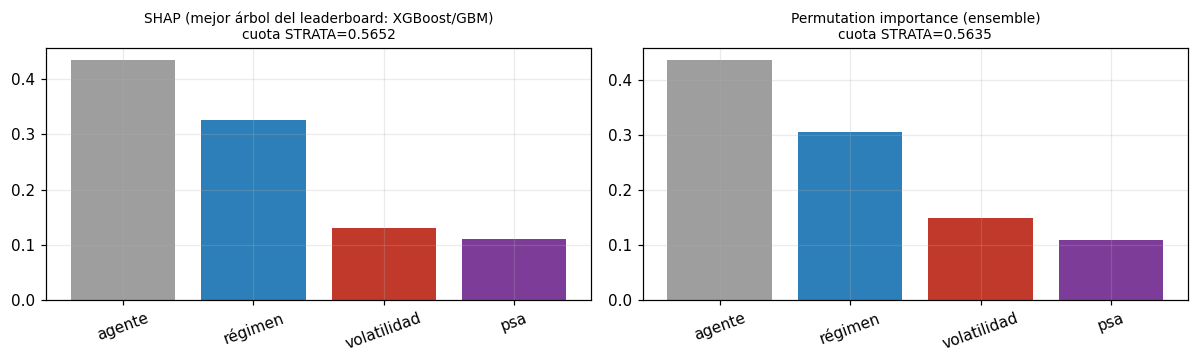

Nota: un ENSEMBLE no admite atribución exacta por feature → SHAP se saca del ÁRBOL (mejor XGBoost del leaderboard); el ensemble se reporta con permutation importance (model-agnostic, sensible a correlación).


In [6]:
# ¿En qué se apoya el modelo en SPY? Importancia de features (AutoML) — método correcto por modelo
imp = IMP.get("SPY", {})
print("Leader AutoML en SPY:", imp.get("leader_family", "?"))
sx = imp.get("shap_tree", {}); pe = imp.get("perm_importance_ensemble", {})
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, dat, ttl in [(axes[0], sx, "SHAP (mejor árbol del leaderboard: XGBoost/GBM)"),
                     (axes[1], pe, "Permutation importance (ensemble)")]:
    bl = dat.get("bloques")
    if bl:
        ks = list(bl); ax.bar(ks, [bl[k] for k in ks], color=["#9e9e9e", "#2c7fb8", "#c0392b", "#7d3c98"])
        ax.set_title(f"{ttl}\ncuota STRATA={dat.get('cuota_strata','?')}", fontsize=9)
        ax.tick_params(axis="x", rotation=20)
    else:
        ax.text(0.5, 0.5, dat.get("error", dat.get("warning", "n/d")), ha="center", va="center", fontsize=8)
        ax.set_title(ttl, fontsize=9)
plt.tight_layout(); plt.show()
print("Nota: un ENSEMBLE no admite atribución exacta por feature → SHAP se saca del ÁRBOL (mejor XGBoost del "
      "leaderboard); el ensemble se reporta con permutation importance (model-agnostic, sensible a correlación).")

## §2. ¿Tiene efecto STRATA en todo el panel? (universalidad §2.3)

Dos lecturas complementarias sobre el M10 canónico (XGBoost, las features limpias):
- **Ablación** — accuracy/Sharpe con solo las 15 features del agente vs las 22 (agente + STRATA). El Δ mide
  cuánto **añade** STRATA.
- **SHAP por bloque** — de qué features se fía el modelo. Si las **STRATA** dominan, el ML *redescubre* la
  señal de STRATA (hipótesis de universalidad).

In [7]:
# Ablación por activo: Δaccuracy (ALL22 − agente15) y cuota STRATA en SHAP
rows = []
for a in ASSETS:
    abl = DPA[a]["ablation"]; sh = DPA[a]["shap"]
    rows.append({"activo": a, "acc_agente15": abl["acc"]["agente15"], "acc_all22": abl["acc"]["all22"],
                 "Δacc_STRATA": abl["d_acc_strata"], "ΔSharpe_STRATA": abl["d_sharpe_strata"],
                 "cuota_STRATA_SHAP": sh["cuota_strata"]})
T = pd.DataFrame(rows).set_index("activo")
with pd.option_context("display.float_format", lambda v: f"{v:.3f}"):
    print(T)
print("\nMedias panel:  Δacc STRATA =", DP["medias"]["d_acc_strata"],
      "· cuota STRATA SHAP =", DP["medias"]["cuota_strata_shap"])

        acc_agente15  acc_all22  Δacc_STRATA  ΔSharpe_STRATA  \
activo                                                         
SPY            0.542      0.494       -0.048          -1.659   
QQQ            0.538      0.522       -0.016          -0.978   
DIA            0.464      0.468        0.004           1.577   
IWM            0.478      0.458       -0.020          -1.283   
XLE            0.548      0.508       -0.040          -1.768   
XLF            0.502      0.526        0.024          -0.736   
XLK            0.606      0.542       -0.064          -1.271   
NVDA           0.521      0.483       -0.039          -0.695   
BAC            0.500      0.419       -0.081          -2.592   
TSLA           0.498      0.522        0.024           1.124   
MSTR           0.458      0.534        0.076           1.688   
SMCI           0.468      0.552        0.084           3.878   
ROKU           0.508      0.508        0.000           0.379   
MARA           0.472      0.532        0

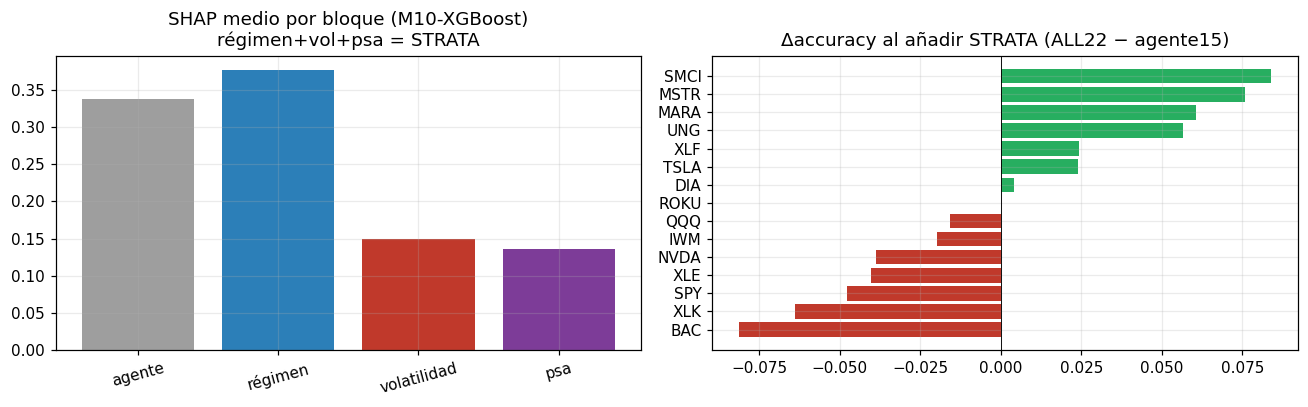

Honesto: el modelo SE APOYA en STRATA (cuota alta), pero meter STRATA al meta-learner no siempre sube su accuracy OOS (Δ mixto) — el efecto robusto de STRATA es el RESCATE del agente (§1, §3).


In [8]:
# Figura: cuota SHAP por bloque (media panel) + Δacc STRATA por activo
bloN = list(DP["meta"]["bloques"])
blo_mean = {b: np.mean([DPA[a]["shap"]["bloques"][b] for a in ASSETS]) for b in bloN}
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].bar(bloN, [blo_mean[b] for b in bloN], color=["#9e9e9e", "#2c7fb8", "#c0392b", "#7d3c98"])
axes[0].set_title("SHAP medio por bloque (M10-XGBoost)\nrégimen+vol+psa = STRATA"); axes[0].tick_params(axis="x", rotation=15)
dac = T["Δacc_STRATA"].sort_values()
axes[1].barh(dac.index, dac.values, color=["#27ae60" if v > 0 else "#c0392b" for v in dac.values])
axes[1].axvline(0, color="k", lw=0.6); axes[1].set_title("Δaccuracy al añadir STRATA (ALL22 − agente15)")
plt.tight_layout(); plt.show()
print("Honesto: el modelo SE APOYA en STRATA (cuota alta), pero meter STRATA al meta-learner no siempre "
      "sube su accuracy OOS (Δ mixto) — el efecto robusto de STRATA es el RESCATE del agente (§1, §3).")

## §3. Rendimiento del panel (accuracy · Sharpe · maxDD)

Accuracy como medida central, con Sharpe y max drawdown. Los ganadores en accuracy frente a ZeroR son
**nominales** (no significativos, ventana corta). El valor robusto —**riesgo**— se contrasta con bootstrap
pareado **pooled** (15 activos concatenados → potencia real).

        M5    M8   M10  AutoML  ZeroR   B&H ZeroR_gana
SPY  0.366 0.442 0.494   0.574  0.566 0.566         no
QQQ  0.418 0.486 0.522   0.534  0.590 0.590         sí
DIA  0.440 0.484 0.468   0.520  0.552 0.556         no
IWM  0.450 0.470 0.458   0.482  0.554 0.574         no
XLE  0.448 0.528 0.508   0.532  0.565 0.565         sí
XLF  0.429 0.502 0.526   0.510  0.538 0.538         sí
XLK  0.510 0.470 0.542   0.590  0.641 0.641         sí
NVDA 0.467 0.521 0.483   0.517  0.552 0.552         sí
BAC  0.451 0.516 0.419   0.488  0.561 0.561         sí
TSLA 0.474 0.478 0.522   0.454  0.458 0.530         no
MSTR 0.554 0.558 0.534   0.498  0.530 0.450         no
SMCI 0.484 0.496 0.552   0.472  0.516 0.484         no
ROKU 0.444 0.528 0.508   0.544  0.548 0.548         sí
MARA 0.528 0.528 0.532   0.544  0.532 0.468         no
UNG  0.510 0.502 0.518   0.482  0.449 0.486         no


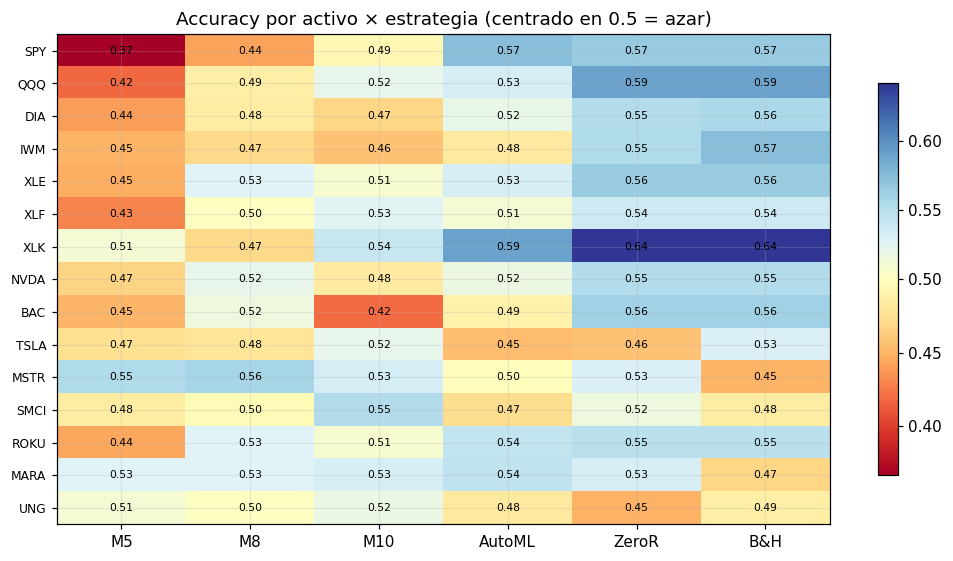

In [9]:
# Tabla maestra panel (accuracy) + heatmap centrado en 0.5
acc = pd.DataFrame({s: {a: PAN[a]["table"][PKEY[s]]["accuracy"] for a in ASSETS} for s in COL}).loc[ASSETS]
acc["ZeroR_gana"] = acc.idxmax(axis=1).eq("ZeroR").map({True: "sí", False: "no"})
with pd.option_context("display.float_format", lambda v: f"{v:.3f}"):
    print(acc)
M = acc[list(COL)].astype(float)
fig, ax = plt.subplots(figsize=(9.5, 5.2))
norm = TwoSlopeNorm(vmin=float(M.min().min()), vcenter=0.5, vmax=float(M.max().max()))
im = ax.imshow(M.values, cmap="RdYlBu", norm=norm, aspect="auto")
ax.set_xticks(range(len(COL))); ax.set_xticklabels(list(COL))
ax.set_yticks(range(len(ASSETS))); ax.set_yticklabels(ASSETS, fontsize=8)
for i in range(len(ASSETS)):
    for j, s in enumerate(COL):
        ax.text(j, i, f"{M.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Accuracy por activo × estrategia (centrado en 0.5 = azar)"); fig.colorbar(im, shrink=0.8)
plt.tight_layout(); plt.show()

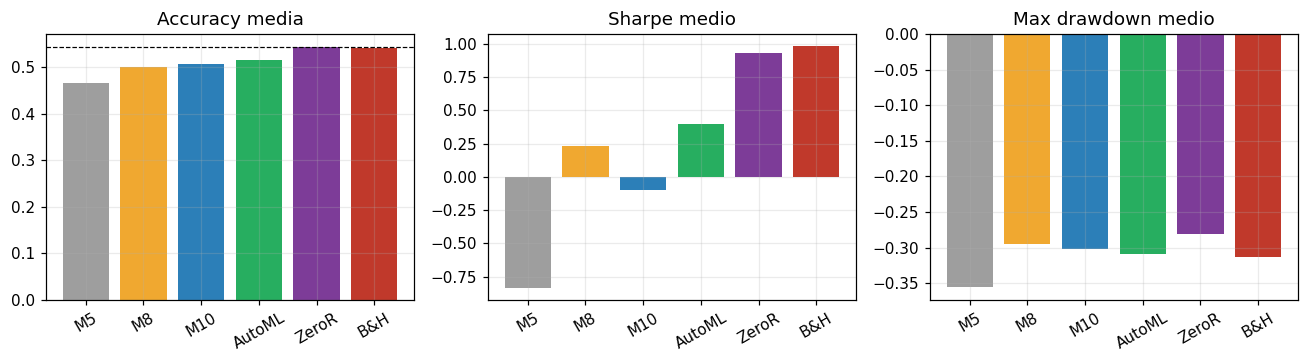

M5 (agente) es el peor en todo; M8/M10/AutoML lo rescatan. Frente a ZeroR/B&H (línea), el agente supervisado se acerca pero en media no lo supera en accuracy.


In [10]:
# Rescate del agente: medias panel M5 vs M8/M10/AutoML en acc, Sharpe, maxDD
med = {s: {"acc": np.mean([PAN[a]["table"][PKEY[s]]["accuracy"] for a in ASSETS]),
           "Sharpe": np.mean([PAN[a]["table"][PKEY[s]]["sharpe"] for a in ASSETS]),
           "maxDD": np.mean([PAN[a]["table"][PKEY[s]]["max_dd"] for a in ASSETS])} for s in COL}
mt = pd.DataFrame(med).T
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, k, ttl in [(axes[0], "acc", "Accuracy media"), (axes[1], "Sharpe", "Sharpe medio"),
                   (axes[2], "maxDD", "Max drawdown medio")]:
    ax.bar(mt.index, mt[k].values, color=[COL[s] for s in mt.index]); ax.set_title(ttl)
    ax.tick_params(axis="x", rotation=30)
    if k == "acc": ax.axhline(mt.loc["ZeroR", "acc"], color="k", ls="--", lw=0.8)
plt.tight_layout(); plt.show()
print("M5 (agente) es el peor en todo; M8/M10/AutoML lo rescatan. Frente a ZeroR/B&H (línea), el agente "
      "supervisado se acerca pero en media no lo supera en accuracy.")

=== POOLED (n=3751 días, 15 activos) ===
 comparación  ΔSharpe        Sharpe_IC95 Sharpe_sig  ΔmaxDD        maxDD_IC95 maxDD_sig
    m8_vs_m5   0.6641    [0.2252, 1.157]        SIG  0.2424  [0.0171, 0.4447]       SIG
    m8_vs_bh   0.0144  [-0.8193, 0.8726]          —  0.1556  [-0.296, 0.3595]         —
 m8_vs_zeror  -0.4127 [-0.8638, -0.0319]        SIG  0.0104 [-0.3491, 0.0737]         —
   m10_vs_m5   0.6077  [-0.0372, 1.2453]          —  0.2301  [-0.016, 0.4545]         —
   m10_vs_bh  -0.0420  [-0.7901, 0.6572]          —  0.1433 [-0.2945, 0.3466]         —
m10_vs_zeror  -0.4691  [-1.1774, 0.1434]          — -0.0019 [-0.4283, 0.2072]         —


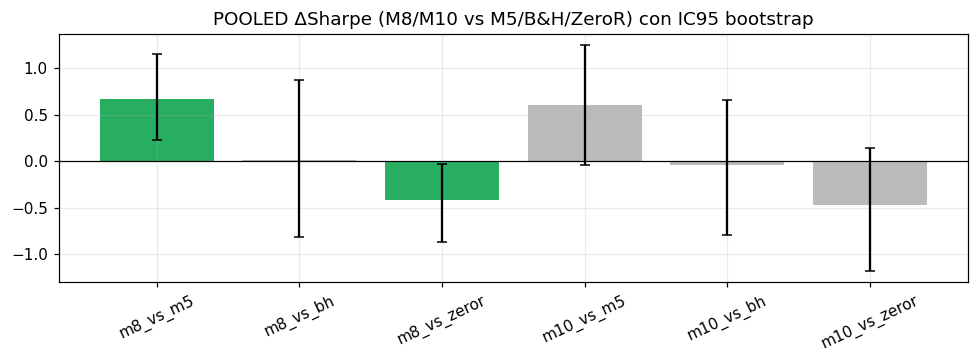

Donde el IC excluye 0 (verde) la diferencia de riesgo es significativa. El signo dice quién gana: vs M5 STRATA gana; vs B&H/ZeroR el signo depende (en el pool dominan los activos alcistas).


In [11]:
# Significancia de RIESGO (lo robusto): bootstrap POOLED de ΔSharpe y ΔmaxDD
pb = DP["pooled"]["boot"]
print(f"=== POOLED (n={DP['pooled']['n_total']} días, {DP['pooled']['n_activos']} activos) ===")
rows = []
for key, v in pb.items():
    rows.append({"comparación": key, "ΔSharpe": v["dSharpe"]["point"], "Sharpe_IC95": str(v["dSharpe"]["ci95"]),
                 "Sharpe_sig": "SIG" if v["dSharpe"]["sig"] else "—",
                 "ΔmaxDD": v["dMaxDD"]["point"], "maxDD_IC95": str(v["dMaxDD"]["ci95"]),
                 "maxDD_sig": "SIG" if v["dMaxDD"]["sig"] else "—"})
print(pd.DataFrame(rows).to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 3.4))
labels = list(pb); pts = [pb[k]["dSharpe"]["point"] for k in labels]
err = [[pb[k]["dSharpe"]["point"] - pb[k]["dSharpe"]["ci95"][0] for k in labels],
       [pb[k]["dSharpe"]["ci95"][1] - pb[k]["dSharpe"]["point"] for k in labels]]
cols = ["#27ae60" if pb[k]["dSharpe"]["sig"] else "#bbb" for k in labels]
ax.bar(labels, pts, yerr=err, color=cols, capsize=3); ax.axhline(0, color="k", lw=0.8)
ax.set_title("POOLED ΔSharpe (M8/M10 vs M5/B&H/ZeroR) con IC95 bootstrap"); ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()
print("Donde el IC excluye 0 (verde) la diferencia de riesgo es significativa. El signo dice quién gana: "
      "vs M5 STRATA gana; vs B&H/ZeroR el signo depende (en el pool dominan los activos alcistas).")

## §4. Agrupación por naturaleza del activo — ¿qué estrategia gana en cada grupo?

No todos los activos son iguales: el **leverage effect**, la volatilidad y el sesgo del agente cambian. Si los
activos se agrupan por su naturaleza, ¿emerge un patrón de qué estrategia/modelo conviene en cada grupo?

Probamos **varios algoritmos** adecuados a datos pequeños y continuos (n=15): KMeans, Ward (jerárquico),
GaussianMixture (+BIC) y Spectral. **La elección final del algoritmo es decisión de Raquel** — aquí se
muestra cómo separa cada uno y cuánto coinciden.

In [12]:
# Comparación de algoritmos: silhouette por método y k
import pandas as pd
clus = CLU["clustering"]
sil = pd.DataFrame({k: {mth: clus[k][mth].get("silhouette") for mth in ("kmeans", "ward", "gmm", "spectral")}
                    for k in ("k2", "k3", "k4")})
print("=== Silhouette (mayor = mejor separación) ==="); print(sil)
print("\nGMM BIC (menor = mejor):", {k: clus[k]["gmm"].get("bic") for k in ("k2", "k3", "k4")})
print("Concordancia entre métodos a k=3 (Rand ajustado, 1=idénticos):", CLU["concordancia_k3_randajustado"])

=== Silhouette (mayor = mejor separación) ===
              k2      k3      k4
kmeans    0.4587  0.4852  0.4560
ward      0.4587  0.4852  0.4560
gmm       0.3601  0.4852  0.4560
spectral  0.4587  0.1797  0.2099

GMM BIC (menor = mejor): {'k2': 122.13, 'k3': 14.67, 'k4': -27.78}
Concordancia entre métodos a k=3 (Rand ajustado, 1=idénticos): {'kmeans~ward': 1.0, 'kmeans~gmm': 1.0, 'kmeans~spectral': 0.401, 'ward~gmm': 1.0, 'ward~spectral': 0.401, 'gmm~spectral': 0.401}


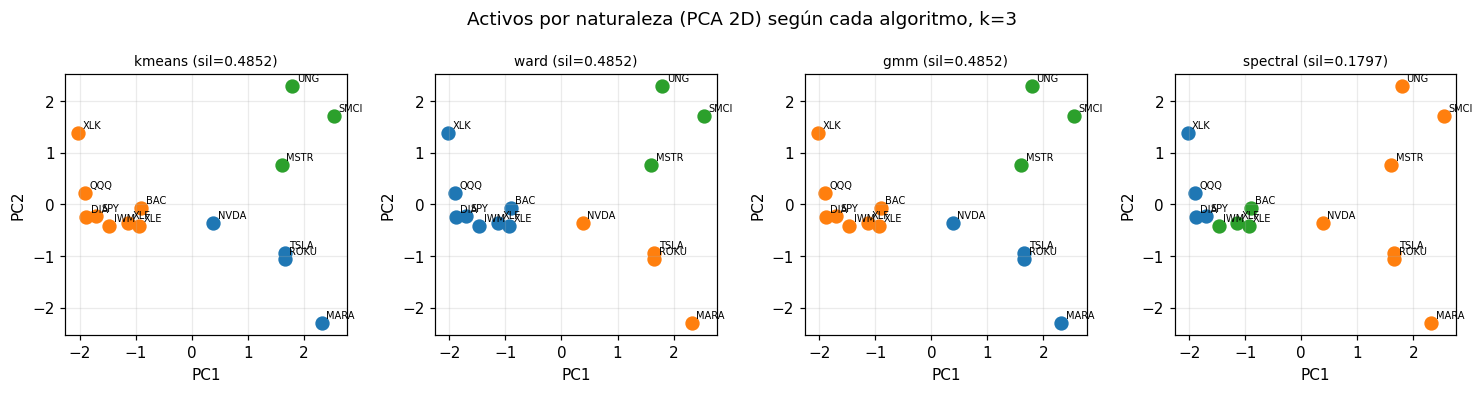

In [13]:
# PCA 2D de la naturaleza, coloreado por cada método (k=3)
from sklearn.decomposition import PCA
Xs = np.array(CLU["meta"]["X_estandarizada"]); ok = CLU["meta"]["panel"]
pca = PCA(n_components=2).fit_transform(Xs)
mets = [m for m in ("kmeans", "ward", "gmm", "spectral") if "labels" in clus["k3"][m]]
fig, axes = plt.subplots(1, len(mets), figsize=(3.4 * len(mets), 3.6), squeeze=False)
for ax, mth in zip(axes[0], mets):
    lab = np.array(clus["k3"][mth]["labels"])
    for c in sorted(set(lab)):
        ax.scatter(pca[lab == c, 0], pca[lab == c, 1], s=70, label=f"C{c}")
    for i, t in enumerate(ok):
        ax.annotate(t, (pca[i, 0], pca[i, 1]), fontsize=6.5, xytext=(3, 3), textcoords="offset points")
    ax.set_title(f"{mth} (sil={clus['k3'][mth]['silhouette']})", fontsize=9)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
fig.suptitle("Activos por naturaleza (PCA 2D) según cada algoritmo, k=3"); plt.tight_layout(); plt.show()

In [14]:
# Perfiles de grupo (KMeans k=3 como referencia): naturaleza media + mejor estrategia
prof = CLU["perfiles_k3"].get("kmeans", {})
for c, d in prof.items():
    nat = d["naturaleza_media"]
    print(f"\n{c}: {d['activos']}")
    print(f"   naturaleza: leverage={nat['leverage_corr']:+.3f} crisis_mean={nat['crisis_mean']:+.5f} "
          f"vol={nat['oos_vol']:.2f} agente_corto={nat['agent_short_frac']:.2f}")
    print(f"   acc media: " + " ".join(f"{s}={d['acc_media'][s]:.3f}" for s in ("M5","M8","M10","Régimen","AutoML","ZeroR")))
    print(f"   → mejor no-trivial: accuracy={d['mejor_acc_no_trivial']} · Sharpe={d['mejor_sharpe_no_trivial']}")
print("\nLectura (HIPÓTESIS, n=15 exploratorio): los grupos de leverage fuerte (índices) favorecen "
      "régimen/M8; los volátiles/cripto que caen favorecen M10. Qué algoritmo fijar = decisión de Raquel.")


C0: ['NVDA', 'TSLA', 'ROKU', 'MARA']
   naturaleza: leverage=-0.019 crisis_mean=+0.00360 vol=0.65 agente_corto=0.93
   acc media: M5=0.478 M8=0.514 M10=0.511 Régimen=0.509 AutoML=0.515 ZeroR=0.541
   → mejor no-trivial: accuracy=AutoML · Sharpe=M10

C1: ['SPY', 'QQQ', 'DIA', 'IWM', 'XLE', 'XLF', 'XLK', 'BAC']
   naturaleza: leverage=-0.093 crisis_mean=-0.00040 vol=0.18 agente_corto=0.68
   acc media: M5=0.439 M8=0.487 M10=0.492 Régimen=0.548 AutoML=0.529 ZeroR=0.574
   → mejor no-trivial: accuracy=Régimen · Sharpe=Régimen

C2: ['MSTR', 'SMCI', 'UNG']
   naturaleza: leverage=+0.018 crisis_mean=-0.00050 vol=0.69 agente_corto=0.98
   acc media: M5=0.516 M8=0.519 M10=0.535 Régimen=0.483 AutoML=0.484 ZeroR=0.527
   → mejor no-trivial: accuracy=M10 · Sharpe=M8

Lectura (HIPÓTESIS, n=15 exploratorio): los grupos de leverage fuerte (índices) favorecen régimen/M8; los volátiles/cripto que caen favorecen M10. Qué algoritmo fijar = decisión de Raquel.


## §5. Conclusiones (pitch) y líneas futuras

**Lo que aporta STRATA (demostrado):**
1. **Rescata al agente** (M5): de apuestas direccionales malas y Sharpe muy negativo a riesgo controlado
   (Sharpe/maxDD mucho mejores). Es el valor más robusto y el que sostiene la tesis de supervisión.
2. **El modelo se apoya en las señales STRATA** (SHAP: cuota STRATA alta) → el ML *redescubre* la señal de
   STRATA (universalidad §2.3), no inventa otra.
3. En el **caso SPY** AutoML gana en punto a todas las estrategias (nominal); el régimen es proxy direccional
   por el leverage effect, y el de-risk en Crisis recorta drawdown.
4. **Por grupo de activo** la mejor estrategia cambia (régimen/M8 en índices de leverage; M10 en volátiles).

**Honestidad / líneas futuras:**
- Batir a **ZeroR en accuracy** es **nominal**: con n≈250 no hay potencia. La **significancia de accuracy** y
  la validación con **muestra mayor** (más OOS o pool con corrección de multiplicidad) son **trabajo futuro**.
- La ventaja en **riesgo (Sharpe/maxDD)** sí se contrasta con bootstrap; el "rescate de B&H" es **condicional**
  (real donde el activo cae). En mercados alcistas B&H es difícil de batir — limitación honesta del OOS.

In [15]:
# --- AUTO-TEST: los headlines del notebook cuadran con los JSON auditados ---
assert spy.loc["AutoML", "acc"] == PAN["SPY"]["table"]["automl"]["accuracy"], "SPY AutoML acc ≠ panel"
assert abs(DP["medias"]["d_acc_strata"]) < 0.2, "Δacc STRATA medio fuera de rango esperado"
assert len(ASSETS) == 15, "faltan activos en el panel"
assert set(("dSharpe", "dMaxDD")).issubset(next(iter(DP["pooled"]["boot"].values()))), "faltan boots pooled"
assert all(m in CLU["clustering"]["k3"] for m in ("kmeans", "ward", "gmm")), "faltan métodos de clustering"
print("AUTO-TEST OK · headlines coherentes con decision_automl_prep.json / panel mm25 / clustering15")

AUTO-TEST OK · headlines coherentes con decision_automl_prep.json / panel mm25 / clustering15
